## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

# dataviz reference palette (references/palette.md)
CAT = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID = '#e1e0d9'
BASELINE = '#c3c2b7'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.labelcolor': INK_SECONDARY,
    'text.color': INK_PRIMARY,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'grid.color': GRID,
    'font.size': 9,
    'axes.grid': True,
    'grid.linewidth': 0.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

KPI_COLS = ['throughput_mbps', 'latency_ms', 'packet_loss_pct', 'handover_count',
            'rsrp_dbm', 'rsrq_db', 'prb_utilization_pct', 'active_users']
SLICE_TYPES = ['eMBB', 'mMTC', 'URLLC', 'HC']
SLICE_COLOR = dict(zip(SLICE_TYPES, CAT[:4]))
CELL_TYPES = ['macro', 'micro', 'pico']
CELL_TYPE_COLOR = dict(zip(CELL_TYPES, CAT[:3]))


## Load dataset

In [2]:
df = pd.read_csv('../data/5g_kpi_dataset.csv')
df.shape


(5000, 13)

In [3]:
df.head()


,timestamp,cell_id,cell_type,slice_type,throughput_mbps,latency_ms,packet_loss_pct,handover_count,rsrp_dbm,rsrq_db,prb_utilization_pct,active_users,sla_compliant
0,2024-01-01 00:00:00,CELL_007,micro,eMBB,864.50,6.418,0.4494,3,-97.3,-7.29,56.2,36,1
1,2024-01-01 00:01:00,CELL_020,micro,mMTC,48.97,29.693,0.5957,8,-104.8,-6.69,35.5,197,1
2,2024-01-01 00:02:00,CELL_015,macro,mMTC,53.18,10.869,0.3442,2,-103.8,-14.02,38.6,215,1
3,2024-01-01 00:03:00,CELL_011,macro,mMTC,62.44,25.479,0.5568,3,-87.2,-15.24,33.3,206,1
4,2024-01-01 00:04:00,CELL_008,micro,mMTC,43.89,21.725,0.6820,1,-91.6,-14.06,24.0,199,1


## Dtypes

In [4]:
df.dtypes


timestamp               object
cell_id                 object
cell_type               object
slice_type              object
throughput_mbps        float64
latency_ms             float64
packet_loss_pct        float64
handover_count           int64
rsrp_dbm               float64
rsrq_db                float64
prb_utilization_pct    float64
active_users             int64
sla_compliant            int64
dtype: object

## Null counts

In [5]:
df.isnull().sum()


timestamp              0
cell_id                0
cell_type              0
slice_type             0
throughput_mbps        0
latency_ms             0
packet_loss_pct        0
handover_count         0
rsrp_dbm               0
rsrq_db                0
prb_utilization_pct    0
active_users           0
sla_compliant          0
dtype: int64

## Row counts per (cell_id, slice_type)

In [6]:
group_sizes = df.groupby(['cell_id', 'slice_type'], observed=True).size().rename('row_count')
group_sizes.describe()


count     80.000000
mean      62.500000
std       29.308918
min       18.000000
25%       35.000000
50%       63.000000
75%       84.500000
max      122.000000
Name: row_count, dtype: float64

In [7]:
group_sizes.sort_values().head(10)


cell_id   slice_type
CELL_016  HC            18
CELL_014  HC            19
CELL_010  HC            20
CELL_005  HC            20
CELL_020  HC            21
CELL_011  HC            22
CELL_009  HC            22
CELL_003  HC            23
CELL_018  HC            24
CELL_015  HC            26
Name: row_count, dtype: int64

In [8]:
group_sizes.groupby('slice_type').agg(['min', 'mean', 'max', 'count'])


,min,mean,max,count
slice_type,,,,
HC,18,25.55,35,20
URLLC,56,73.90,92,20
eMBB,82,100.50,122,20
mMTC,34,50.05,71,20


## Summary statistics, numeric KPI columns

In [9]:
df[KPI_COLS].describe().T


,count,mean,std,min,25%,50%,75%,max
throughput_mbps,5000.0,534.767752,401.871383,5.0,191.405000,528.765,858.74250,1827.510
latency_ms,5000.0,9.338260,8.938540,0.3,2.206750,7.202,10.67625,48.867
packet_loss_pct,5000.0,0.477049,0.746633,0.0,0.048275,0.180,0.58495,10.000
handover_count,5000.0,3.054800,1.774944,0.0,2.000000,3.000,4.00000,12.000
rsrp_dbm,5000.0,-94.906040,14.492412,-120.0,-107.500000,-94.600,-82.60000,-70.000
rsrq_db,5000.0,-11.514552,4.934749,-20.0,-15.870000,-11.370,-7.29750,-3.000
prb_utilization_pct,5000.0,60.174000,18.426671,5.0,48.100000,60.700,73.80000,100.000
active_users,5000.0,62.298800,70.630291,1.0,12.000000,41.000,53.00000,251.000


In [10]:
# sla_compliant is a business-rule flag, not a KPI: class balance only
df['sla_compliant'].value_counts(normalize=True).rename('share')


sla_compliant
1    0.9356
0    0.0644
Name: share, dtype: float64

## Timestamp parsing

In [11]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='raise')
df['timestamp'].min(), df['timestamp'].max(), df['timestamp'].is_monotonic_increasing


(Timestamp('2024-01-01 00:00:00'), Timestamp('2024-01-04 11:19:00'), True)

## Monotonicity within each (cell_id, slice_type) group

In [12]:
group_monotonic = df.groupby(['cell_id', 'slice_type'], observed=True)['timestamp'] \
    .apply(lambda s: s.is_monotonic_increasing)
group_monotonic.value_counts()


timestamp
True    80
Name: count, dtype: int64

## Duplicate row check

In [13]:
df.duplicated().sum()


0

In [14]:
# duplicate (timestamp, cell_id, slice_type) would break the rolling-window key
df.duplicated(subset=['timestamp', 'cell_id', 'slice_type']).sum()


0

In [15]:
df['timestamp'].duplicated().sum()


0

## KPI distributions by slice_type

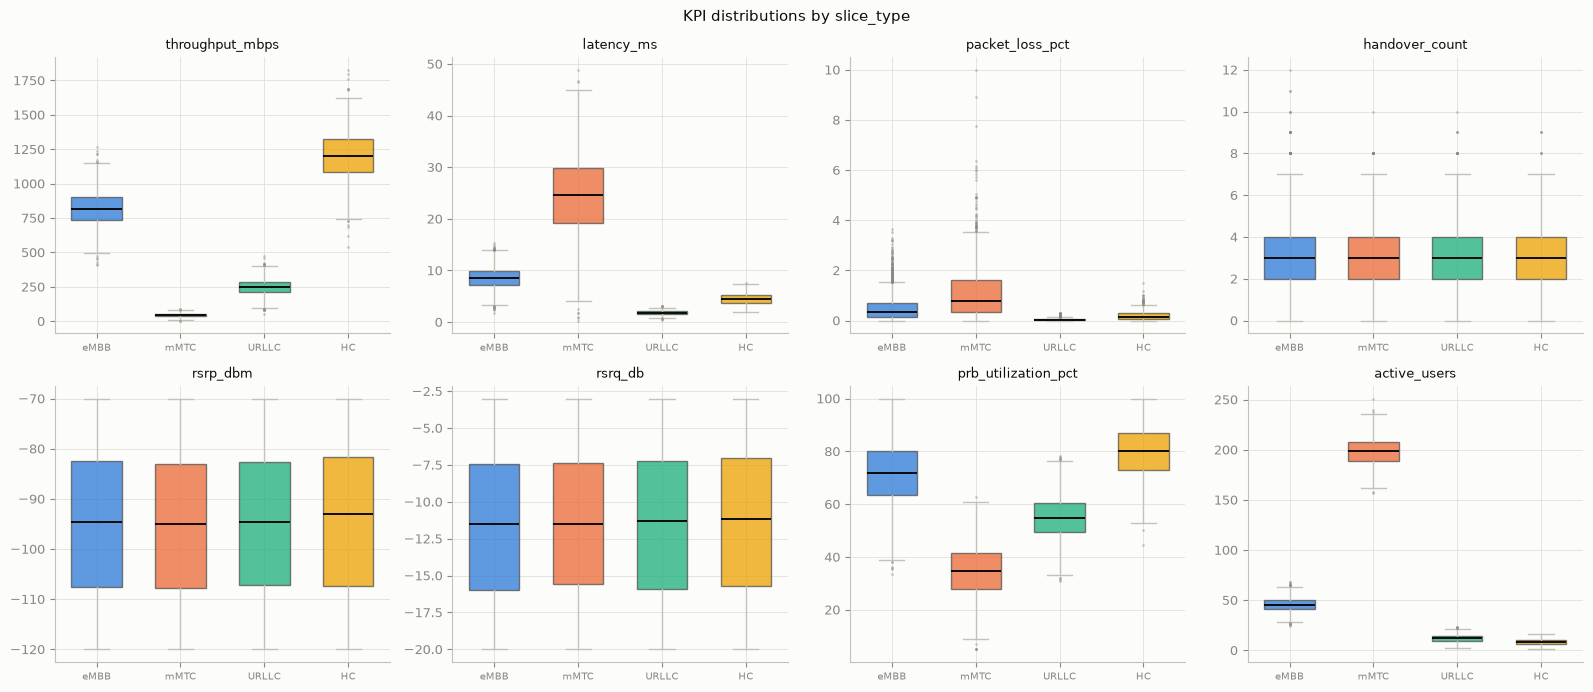

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, KPI_COLS):
    data = [df.loc[df['slice_type'] == s, col].values for s in SLICE_TYPES]
    bp = ax.boxplot(data, tick_labels=SLICE_TYPES, patch_artist=True, widths=0.6,
                     showfliers=True, flierprops=dict(marker='o', markersize=2, alpha=0.4,
                                                        markeredgecolor='none', markerfacecolor=INK_MUTED))
    for patch, s in zip(bp['boxes'], SLICE_TYPES):
        patch.set_facecolor(SLICE_COLOR[s])
        patch.set_alpha(0.75)
        patch.set_edgecolor(INK_SECONDARY)
    for element in ('whiskers', 'caps'):
        for line in bp[element]:
            line.set_color(BASELINE)
    for line in bp['medians']:
        line.set_color(INK_PRIMARY)
        line.set_linewidth(1.4)
    ax.set_title(col, fontsize=9, color=INK_PRIMARY)
    ax.tick_params(axis='x', rotation=0, labelsize=7.5)
fig.suptitle('KPI distributions by slice_type', color=INK_PRIMARY)
fig.tight_layout()
plt.show()


## KPI values over time, representative (cell_id, slice_type) pairs

In [17]:
# largest group per slice_type, one pair per slice_type
rep_pairs = group_sizes.groupby('slice_type', observed=True).idxmax()
rep_pairs


slice_type
HC          (CELL_004, HC)
URLLC    (CELL_015, URLLC)
eMBB      (CELL_015, eMBB)
mMTC      (CELL_017, mMTC)
Name: row_count, dtype: object

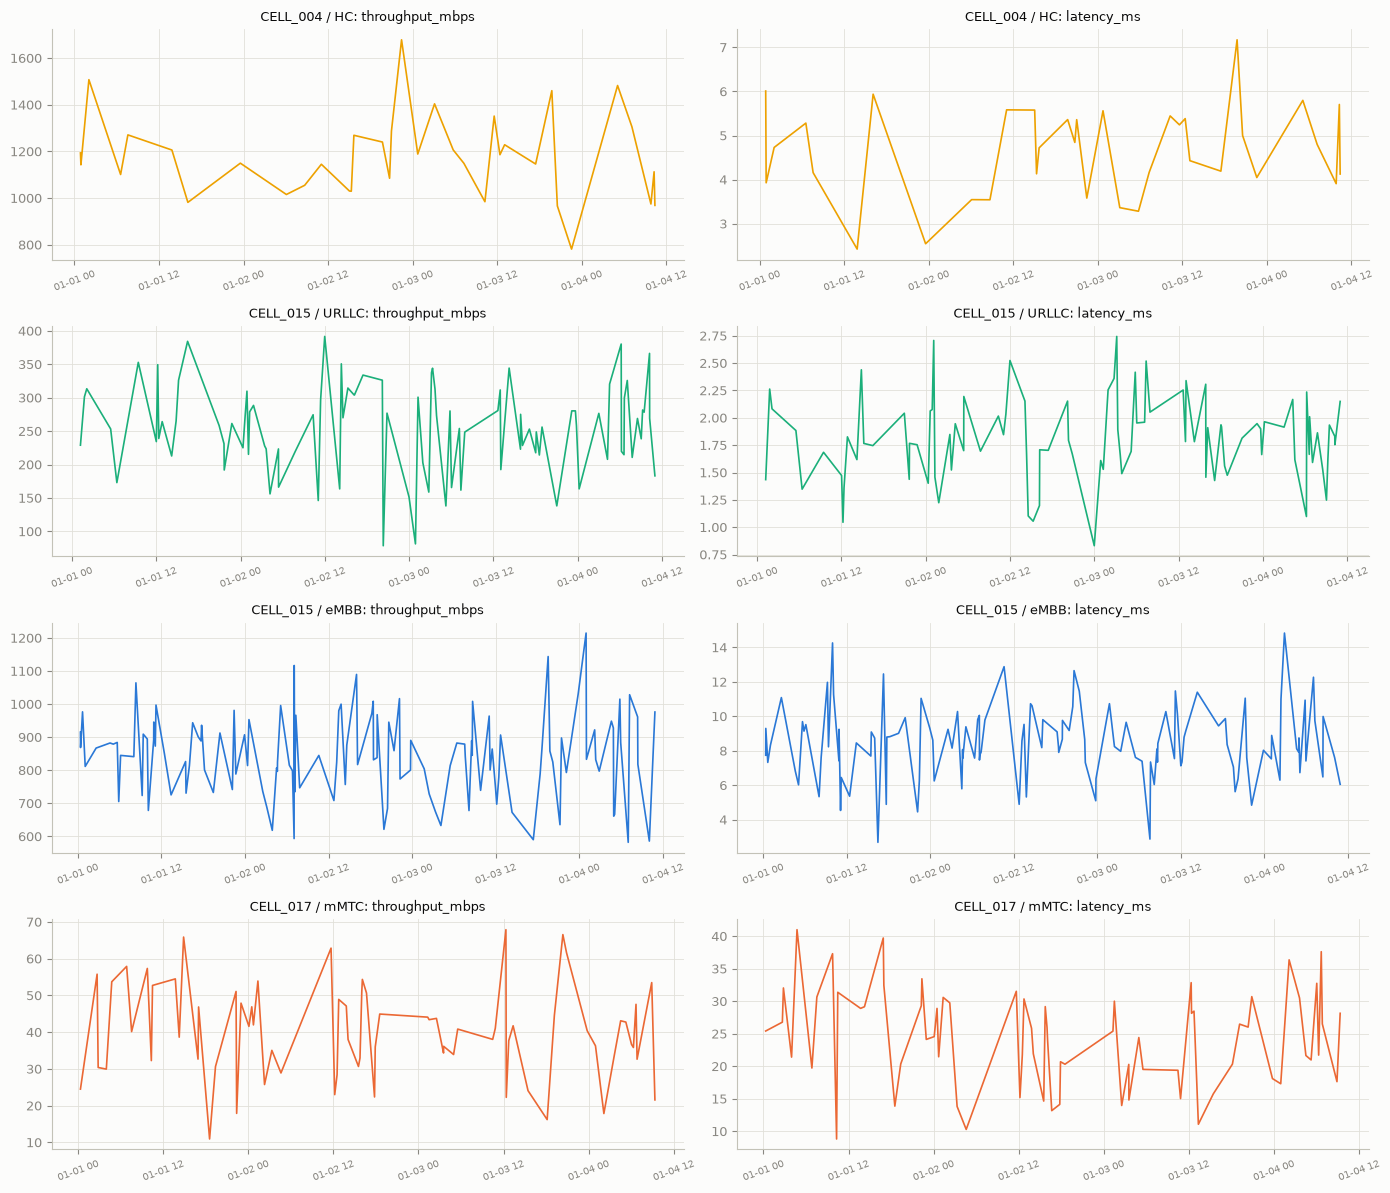

In [18]:
fig, axes = plt.subplots(len(rep_pairs), 2, figsize=(14, 3 * len(rep_pairs)), sharex=False)
for row, (slice_t, (cell_id, _)) in enumerate(rep_pairs.items()):
    sub = df[(df['cell_id'] == cell_id) & (df['slice_type'] == slice_t)].sort_values('timestamp')
    color = SLICE_COLOR[slice_t]
    ax = axes[row, 0]
    ax.plot(sub['timestamp'], sub['throughput_mbps'], color=color, linewidth=1.2)
    ax.set_title(f'{cell_id} / {slice_t}: throughput_mbps', fontsize=9)
    ax.tick_params(axis='x', labelsize=7, rotation=20)
    ax = axes[row, 1]
    ax.plot(sub['timestamp'], sub['latency_ms'], color=color, linewidth=1.2)
    ax.set_title(f'{cell_id} / {slice_t}: latency_ms', fontsize=9)
    ax.tick_params(axis='x', labelsize=7, rotation=20)
fig.tight_layout()
plt.show()


## Row volume over time

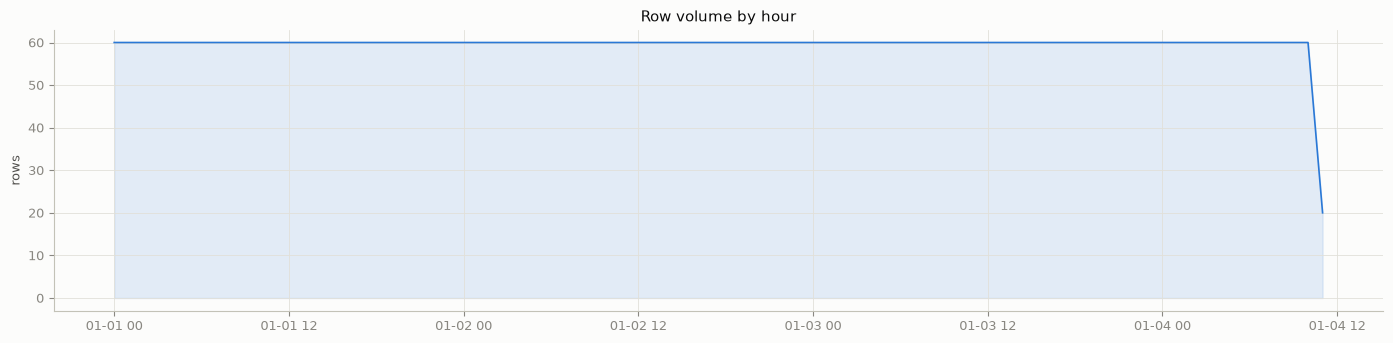

In [19]:
hourly_volume = df.set_index('timestamp').resample('1h').size()
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(hourly_volume.index, hourly_volume.values, color=CAT[0], linewidth=1.2)
ax.fill_between(hourly_volume.index, hourly_volume.values, color=CAT[0], alpha=0.12)
ax.set_title('Row volume by hour', color=INK_PRIMARY)
ax.set_ylabel('rows')
fig.tight_layout()
plt.show()


## Segmentation check: sla_compliant rate by cell_type

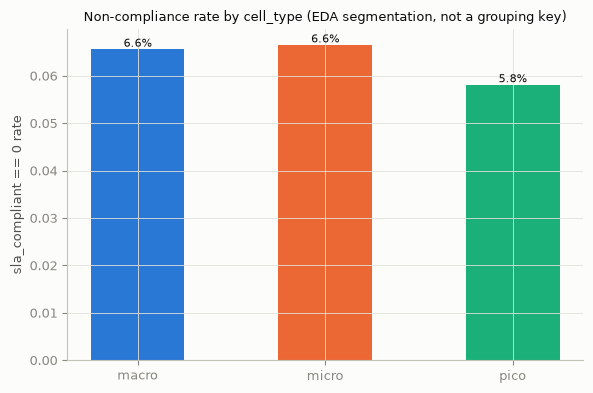

In [20]:
rate_by_cell_type = df.groupby('cell_type', observed=True)['sla_compliant'] \
    .apply(lambda s: 1 - s.mean()).reindex(CELL_TYPES)
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(rate_by_cell_type.index, rate_by_cell_type.values,
               color=[CELL_TYPE_COLOR[c] for c in rate_by_cell_type.index], width=0.5)
ax.set_ylabel('sla_compliant == 0 rate')
ax.set_title('Non-compliance rate by cell_type (EDA segmentation, not a grouping key)', fontsize=9)
for b, v in zip(bars, rate_by_cell_type.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1%}', ha='center', va='bottom', fontsize=8, color=INK_PRIMARY)
fig.tight_layout()
plt.show()


In [21]:
rate_by_cell_type


cell_type
macro    0.065580
micro    0.066484
pico     0.058091
Name: sla_compliant, dtype: float64